## Check sensitivities to parameters

初期条件のtemp_sea_initとtemp_air_initの温度差=0 or 5をtuning対象とした場合。

In [15]:
import warnings
warnings.filterwarnings("ignore")
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
mpl.rcParams['font.family'] = 'sans-serif'
# 優先順位を Helvetica → Arial の順に設定（必要なら他のフォントを追加）
mpl.rcParams['font.sans-serif'] = ['Helvetica', 'Arial']    
from param_test_each_ini import set_param

In [16]:
param_fix_dict = {
    "temp_sea_init_list": [5, 10, 15]    ,
    "BOOL_REEVAP": False, # 十分湿っている雲には返らない
    "temp_surf": [0],
}

## Calc d-excess

In [3]:
def calc_dex(dD, d18O):
    return dD - 8 * d18O

ind=0

def read_csvfile(ind=0, title="tuning_parallel", ISO_TYPE="HDO"):
    df_HDO = pd.read_csv(f"tables/{title}_HDO_{ind}.csv")
    df_H218O = pd.read_csv(f"tables/{title}_H218O_{ind}.csv")

    df_dex = df_HDO.copy()
    for param in ["snow_delta", "ry_fin_delta", "obs_fin_delta"]:
        df_dex[param] = calc_dex(df_HDO[param], df_H218O[param])
    if ISO_TYPE == "HDO":
        return df_HDO
    elif ISO_TYPE == "H218O":
        return df_H218O
    elif ISO_TYPE == "dex":
        return df_dex
    else:
        raise ValueError(f"ISO_TYPE is invalid: {ISO_TYPE}")

## plot all parameters

In [4]:
ylabel_dict = {
    "HDO": "$\mathsf{\delta D}$",
    "H218O": "$\mathsf{\delta ^{18}O}$",
    "dex": "d-excess"
}

ylim_dict = {
    "HDO": (-176,-88),
    "H218O": (-22,-11),
    "dex": (-20,10)
}

In [11]:
def compute_mean(
    df: pd.DataFrame, 
    y_var: str, 
    param: str, 
    param_val
) -> float:
    filtered_vals = df.loc[df[param] == param_val, y_var].replace(-np.inf, np.nan)
    if len(filtered_vals) == 0:
        print(f"param={param}, param_val={param_val}, df[param]={df[param]}")
    return np.nanmean(filtered_vals)

def compute_median(
    df: pd.DataFrame, 
    y_var: str, 
    param: str, 
    param_val
) -> float:
    filtered_vals = df.loc[df[param] == param_val, y_var].replace(-np.inf, np.nan)
    if len(filtered_vals) == 0:
        print(f"param={param}, param_val={param_val}, df[param]={df[param]}")
    return np.nanmedian(filtered_vals)
def plot_violinplot(
    df: pd.DataFrame, 
    y_var: str, 
    param_name: str, 
    means, 
    ISO_TYPE: str, 
    title: str
) -> None:
                           
    plt.figure(figsize=(6,6))
    plt.title(title)
    ax = sns.violinplot(data=df, y=y_var, hue=param_name)
                           
    if means is not None:
        mean_labels = [f"{val:.2f}" for val in means]
        handles, labels = ax.get_legend_handles_labels()
        new_labels = [f"{l} (median={m})" for l, m in zip(labels, mean_labels)]
        ax.legend(handles, new_labels, title=param_name)
    else:
        ax.legend()
        
    ax.set_ylabel(f"Final water vapor {ylabel_dict[ISO_TYPE]} [‰]")
    ax.set_ylim(ylim_dict[ISO_TYPE])
    plt.show()

def check_sensitivity(
    y_var: str ="obs_fin_delta", 
    ISO_TYPE: str = "HDO", 
    ind: int = 0, 
    SHOW_FIG: bool =True, 
    ALL_PARAM: bool =True, 
    param_fix_dict: dict = None
) -> None:
    if param_fix_dict is None:
        raise ValueError(f"param_fix_dict must be provided")
        
    sst_ini = param_fix_dict["temp_sea_init_list"][ind]
    param_test_dict = get_param_test_dict(ISO_TYPE, ALL_PARAM)
    
    df = read_csvfile(ind=ind, ISO_TYPE=ISO_TYPE)

    if ALL_PARAM:
        sens_param_list = list(param_test_dict.keys())
        df_filtered = df.copy()
    else:    
        sens_param_list, df_filtered = get_sens_param(param_test_dict, df.copy(), ind)

    mean_dict = {}
    for param in sens_param_list:
        param_name = param[:-5] if param.endswith("_list") else param
        mean_dict[param_name] = {}

        means = []
        try:
            for param_val in param_test_dict[param]:
                param_val_adjusted = param_val[ind] if isinstance(param_val, list) and param_val else param_val

                # mean_val = compute_mean(df_filtered, y_var, param_name, param_val_adjusted)
                mean_val = compute_median(df_filtered, y_var, param_name, param_val_adjusted)
                means.append(mean_val)
                mean_dict[param_name][param_val_adjusted] = mean_val

            if SHOW_FIG:
                title = f"{param_name}\n(temp_sea_init = {sst_ini})"
                plot_violinplot(df_filtered, y_var, param_name, means, ISO_TYPE, title)

        except (ValueError, KeyError, TypeError) as e:
            print(f"Error in {param_name}: {e}")
            
    print("Warning: median is calculated now.")
    return mean_dict

def get_sens_param(param_test_dict: dict, df: pd.DataFrame, ind: int) -> (list, pd.DataFrame):
    # print("Fixed parameters:")
    sens_param_list = []
    for param, val_list in param_test_dict.items():
        if len(val_list) > 1:
            sens_param_list.append(param)
        else:
            fixed_val = val_list[0]
            param_name = param[:-5] if param.endswith("_list") else param
            if param.endswith("_list"):
                fixed_val = fixed_val[ind]
            # print(f"- {param_name}={fixed_val}")
            
            df = df[df[param_name] != fixed_val]
            # print(f"- Excluding {param_name}={fixed_val}")
    return sens_param_list, df

def get_param_test_dict(
    ISO_TYPE: str, 
    ALL_PARAM: bool = True
) -> dict:
    return set_param("HDO", ALL_PARAM) if ISO_TYPE == "dex" else set_param(ISO_TYPE, ALL_PARAM)
    
def compute_mean_anom_ranking(
    mean_dict: dict, ISO_TYPE: str, ind: int, param_fix_dict: dict = None, ALL_PARAM: bool = True) -> pd.DataFrame:

    if param_fix_dict is None:
        raise ValueError("param_fix_dict must be provided")
    sst_ini = param_fix_dict["temp_sea_init_list"][ind]
    # param_test_dict = get_param_test_dict(ISO_TYPE, ALL_PARAM)

    mean_sort_dict={}
    for param, values in mean_dict.items():
        try:
            val_list = list(values.values())
            mean_sort_dict[param] = np.abs(val_list[0]-val_list[-1]) if len(val_list) >= 2 else np.nan

        except KeyError as e:
            print(f"KeyError: {param}: {e}")

    index = f"anom_abs_{ISO_TYPE}_{sst_ini}"
    df_mean_sort = pd.DataFrame(mean_sort_dict, index=[index]).T
        
    return df_mean_sort.sort_values(index, ascending=False)

### dD

In [12]:
for ind in range(len(param_fix_dict["temp_sea_init_list"])):
    mean_dict_HDO = check_sensitivity(param_fix_dict=param_fix_dict, y_var="obs_fin_delta", ISO_TYPE="HDO", SHOW_FIG=False, ind=ind)
    display(compute_mean_anom_ranking(mean_dict_HDO, "HDO", ind, param_fix_dict=param_fix_dict))
    mean_dict_H218O = check_sensitivity(param_fix_dict=param_fix_dict, y_var="obs_fin_delta", ISO_TYPE="H218O", SHOW_FIG=False, ind=ind)
    display(compute_mean_anom_ranking(mean_dict_H218O, "H218O", ind, param_fix_dict=param_fix_dict))
    
    mean_dict_dex = check_sensitivity(param_fix_dict=param_fix_dict, y_var="obs_fin_delta", ISO_TYPE="dex", SHOW_FIG=False, ind=ind)
    display(compute_mean_anom_ranking(mean_dict_dex, "dex", ind, param_fix_dict=param_fix_dict))

,anom_abs_HDO_5
temp_air_fin,6.679823
prcp_duration,3.952066
resub_factor,1.468607
temp_air_init,1.380657
dt,0.634256
prcp_perday,0.596225
p_top,0.194400
h_air,0.175777
ALPHA_RY_MODE,0.078499
surface_wind,0.058173


,anom_abs_H218O_5
temp_air_fin,0.557219
prcp_duration,0.318964
resub_factor,0.114890
h_air,0.090701
temp_air_init,0.078178
surface_wind,0.076937
prcp_perday,0.039261
dt,0.017461
p_top,0.014523
ALPHA_RY_MODE,0.000863


,anom_abs_dex_5
prcp_duration,3.137470
temp_air_fin,2.202034
temp_air_init,2.061030
resub_factor,1.487926
prcp_perday,0.634122
dt,0.291214
p_top,0.275671
ALPHA_RY_MODE,0.212444
h_air,0.104369
surface_wind,0.089761


,anom_abs_HDO_10
prcp_duration,8.509856
temp_air_fin,7.762338
resub_factor,3.925729
temp_air_init,3.351226
prcp_perday,2.174740
p_top,0.666467
dt,0.352615
h_air,0.209416
ALPHA_RY_MODE,0.163725
rh_surf,0.000000


,anom_abs_H218O_10
temp_air_fin,0.635336
prcp_duration,0.620941
resub_factor,0.267418
h_air,0.264393
prcp_perday,0.117969
surface_wind,0.115195
temp_air_init,0.102836
p_top,0.044880
dt,0.028708
ALPHA_RY_MODE,0.000189


,anom_abs_dex_10
prcp_duration,4.036554
temp_air_fin,2.343005
resub_factor,1.897968
temp_air_init,1.887503
prcp_perday,0.998024
ALPHA_RY_MODE,0.436671
dt,0.435682
p_top,0.349153
h_air,0.110041
rh_surf,0.079740


,anom_abs_HDO_15
prcp_duration,11.944138
temp_air_fin,7.185756
resub_factor,6.424286
prcp_perday,3.597365
temp_air_init,2.447479
p_top,1.095278
dt,0.632699
h_air,0.310301
ALPHA_RY_MODE,0.220218
surface_wind,0.185619


,anom_abs_H218O_15
prcp_duration,0.918612
temp_air_fin,0.636089
resub_factor,0.456649
prcp_perday,0.247187
h_air,0.233800
temp_air_init,0.104218
surface_wind,0.093156
p_top,0.076462
dt,0.051340
ALPHA_RY_MODE,0.007697


,anom_abs_dex_15
prcp_duration,5.107205
temp_air_fin,2.591895
resub_factor,2.453431
temp_air_init,1.862696
prcp_perday,1.239258
dt,0.515475
p_top,0.509005
ALPHA_RY_MODE,0.442283
rh_surf,0.195060
surface_wind,0.177849


## plot sensitive parameters

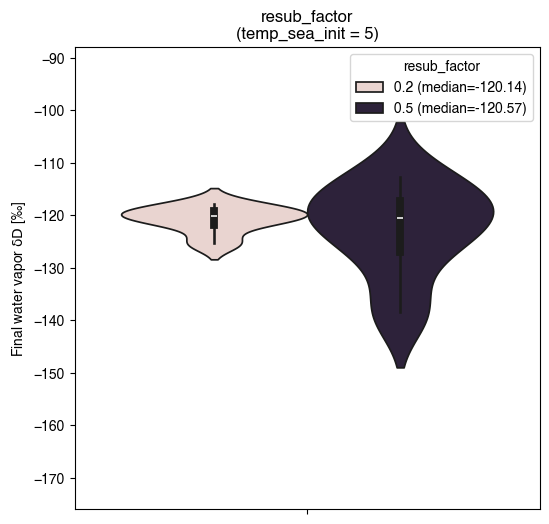

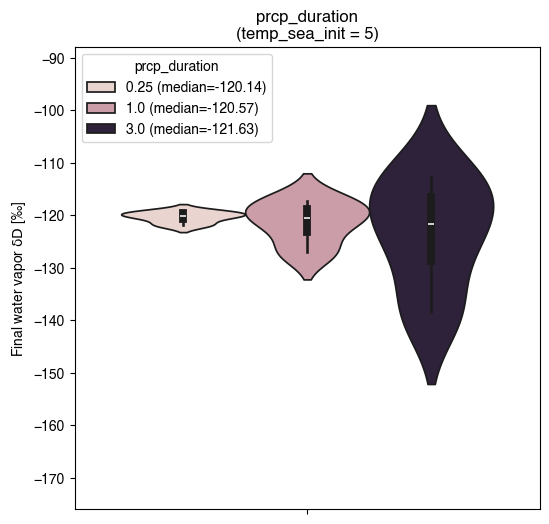

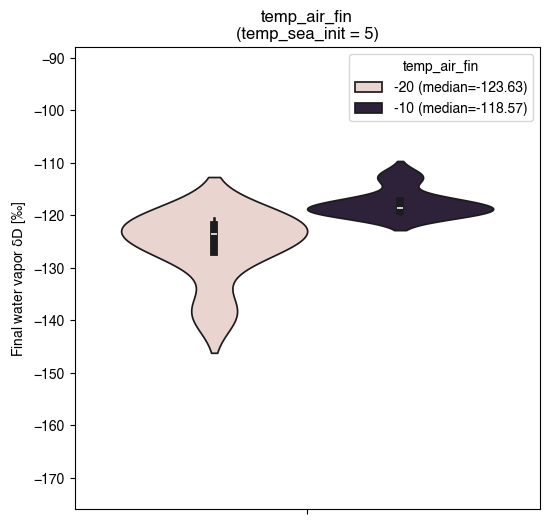

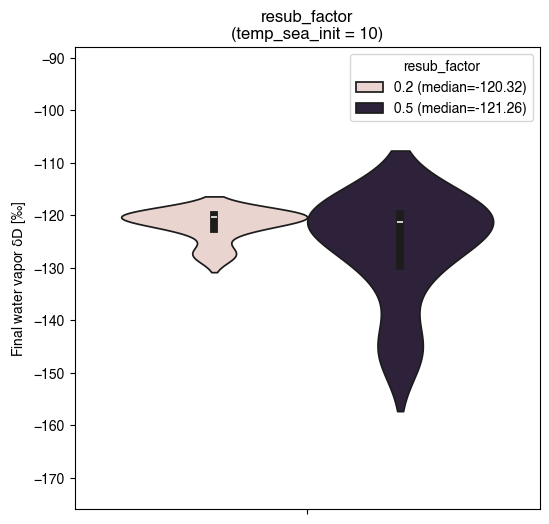

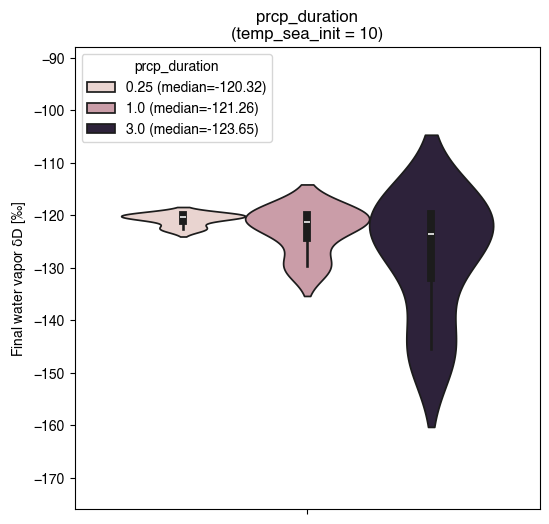

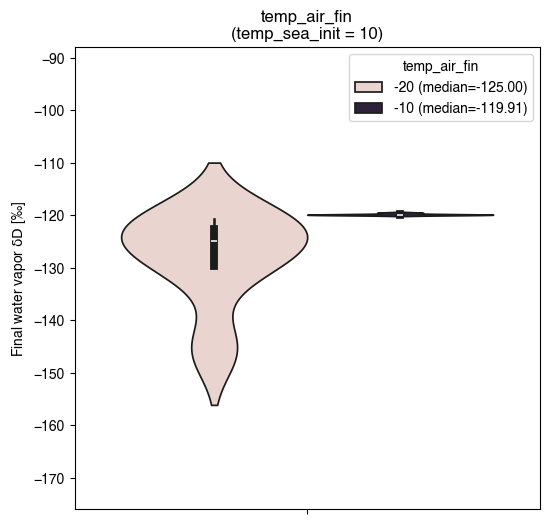

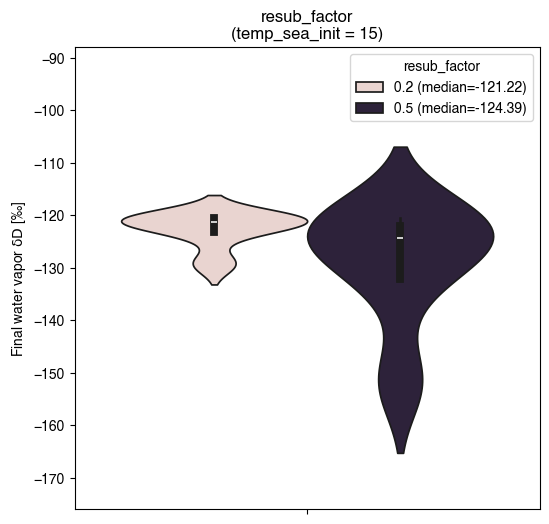

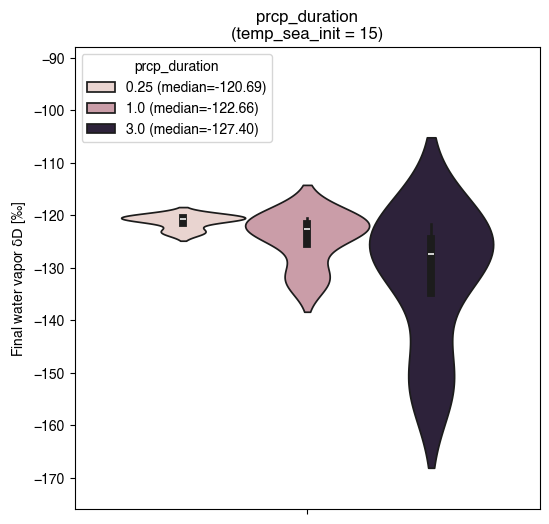

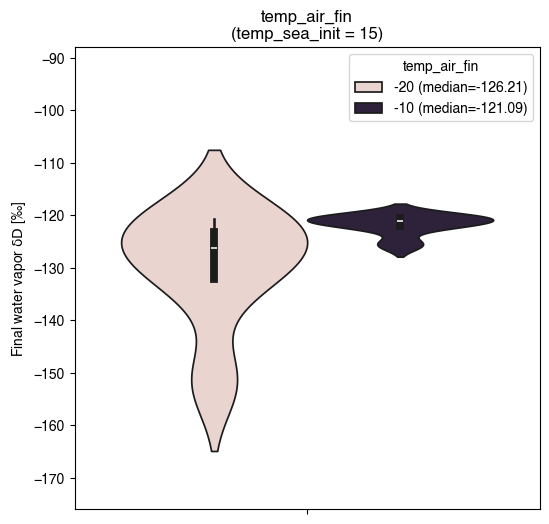

In [13]:
for ind in range(len(param_fix_dict["temp_sea_init_list"])):
    mean_dict_dD_sel = check_sensitivity(y_var="obs_fin_delta", param_fix_dict=param_fix_dict,
                                  ISO_TYPE="HDO", ind=ind, ALL_PARAM=False)
    compute_mean_anom_ranking(mean_dict_dD_sel, "HDO", ind=ind, ALL_PARAM=False, param_fix_dict=param_fix_dict)

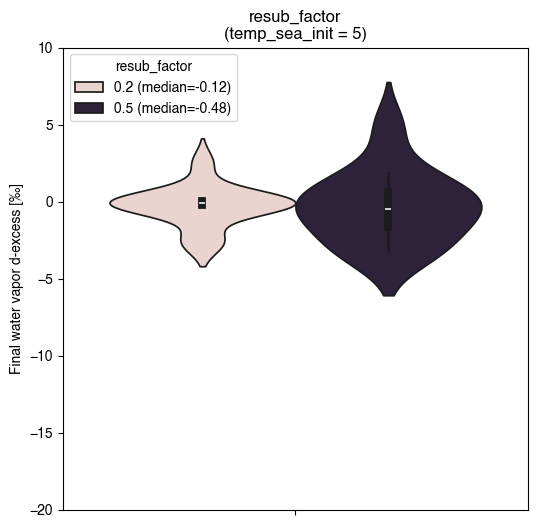

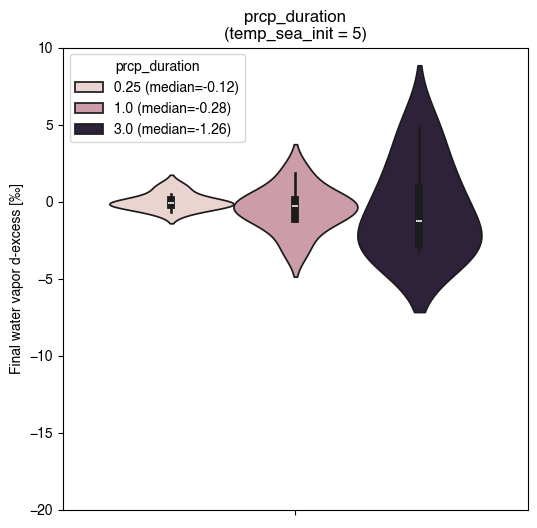

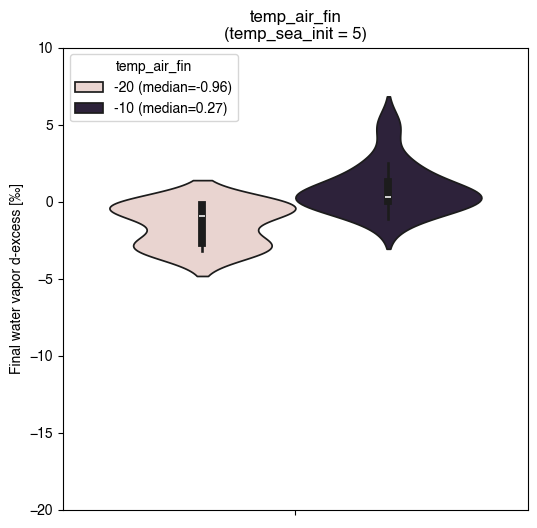

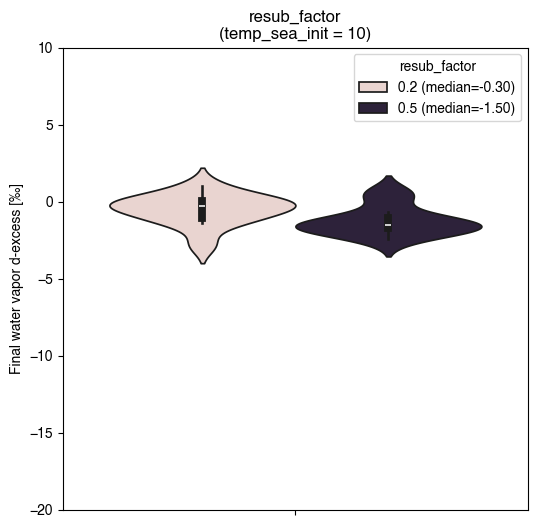

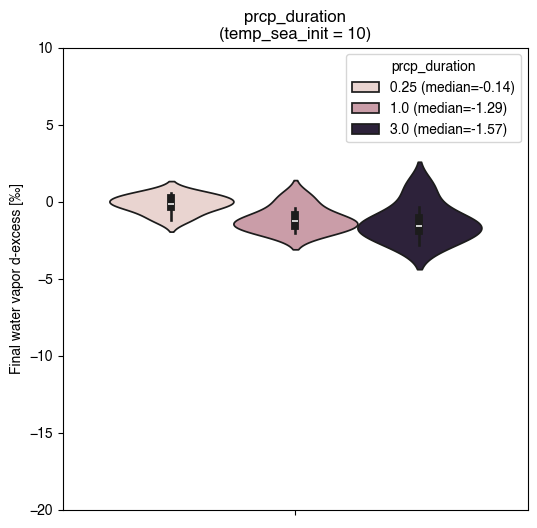

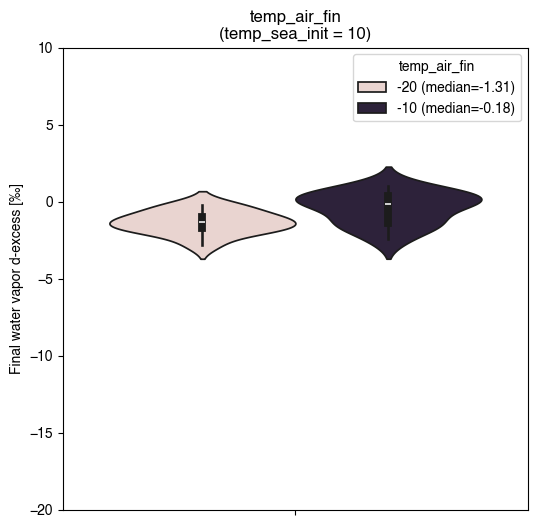

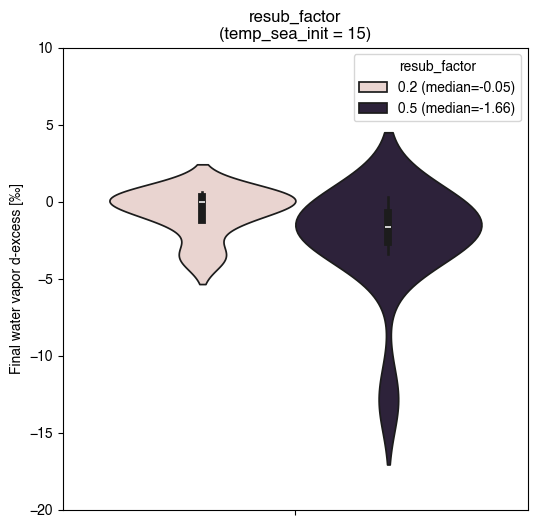

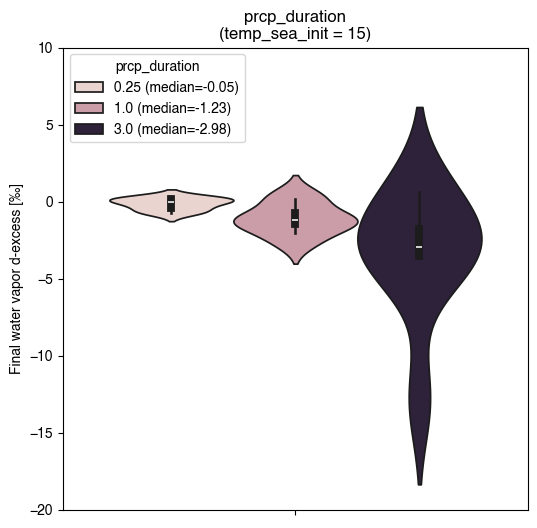

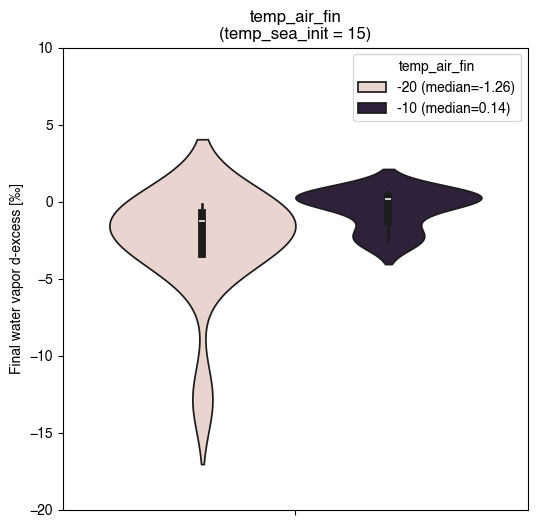

In [14]:
for ind in range(len(param_fix_dict["temp_sea_init_list"])):
    mean_dict_dex_sel = check_sensitivity(y_var="obs_fin_delta", param_fix_dict=param_fix_dict, 
                                      ISO_TYPE="dex", ind=ind, ALL_PARAM=False)
    compute_mean_anom_ranking(mean_dict_dex_sel, "dex", ind=ind, param_fix_dict=param_fix_dict)